# SankhyaVox — GMM Classifier Training

Train and evaluate the GMM baseline on augmented data, test on held-out human speaker.

**Prerequisites:** Run `DataPipeline().build()` and augmentation first.

In [1]:
# ── stdlib ──
import pickle
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Tuple

# ── third-party ──
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Config

In [2]:
# ── Paths ──
DATA_PROCESSED = "/kaggle/input/datasets/devarabhavana/sankhyavox-dataset/data_processed"
PROCESSED_DIR  = DATA_PROCESSED          # alias used by SankhyaVoxDataset default
CHECKPOINT_DIR = Path("./checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Human speaker to hold out for testing
TEST_SPEAKER = "S05"

## SankhyaVoxDataset

**Paste the `SankhyaVoxDataset` class from `dataset/dataset.py` below.**

In [3]:
class SankhyaVoxDataset:
    """
    Unified dataset for SankhyaVox training and evaluation.

    Reads ``<processed_dir>/human.csv``, ``tts.csv``, ``augmented.csv``
    and concatenates them into a single DataFrame.

    Parameters
    ----------
    processed_dir : Path or str, optional
        Root of the processed data tree.  Default: ``config.PROCESSED_DIR``.
    categories : list of str, optional
        Which categories to load.  Default: all CSVs present on disk.

    ``ds[i]`` returns::

        {
            "audio_path":   str,      # path to source .wav segment
            "audio_source": str,      # "human" | "tts" | "augmented"
            "speaker_id":   str,      # e.g. "S01"
            "token":        str,      # Sanskrit label, e.g. "eka"
            "label":        int,      # numeric value, e.g. 1
            "feature":      ndarray,  # shape (n_frames, 39)
        }
    """

    CATEGORIES = ("human", "tts", "augmented")

    def __init__(
        self,
        processed_dir: Optional[Path] = None,
        categories: Optional[List[str]] = None,
    ):
        self._root = (Path(processed_dir) if processed_dir else PROCESSED_DIR).resolve()
        self._categories = categories or list(self.CATEGORIES)
        self._df = self._load_csvs()

    # ── Loading ───────────────────────────────────────────────────────────

    def _load_csvs(self) -> pd.DataFrame:
        """Load and concatenate category CSV files."""
        frames = []
        for cat in self._categories:
            csv_path = self._root / f"{cat}.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df["category"] = cat
                frames.append(df)

        if not frames:
            return pd.DataFrame()

        return pd.concat(frames, ignore_index=True)

    # ── Properties ────────────────────────────────────────────────────────

    @property
    def df(self) -> pd.DataFrame:
        """Full metadata DataFrame."""
        return self._df

    @property
    def speakers(self) -> List[str]:
        """Sorted list of unique speaker IDs."""
        if self._df.empty:
            return []
        return sorted(self._df["speaker"].unique().tolist())

    @property
    def tokens(self) -> List[str]:
        """Sorted list of unique Sanskrit token labels."""
        if self._df.empty:
            return []
        return sorted(self._df["sanskrit_label"].unique().tolist())

    # ── Indexing ──────────────────────────────────────────────────────────

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        """Return a sample dict for the given global index."""
        row = self._df.iloc[idx]
        npy_abs = str(self._root / row["npy_path"])
        wav_abs = str(self._root / row["wav_path"])
        return {
            "audio_path": wav_abs,
            "audio_source": row["category"],
            "speaker_id": row["speaker"],
            "token": row["sanskrit_label"],
            "label": int(row["label"]),
            "feature": np.load(npy_abs),
        }

    def __len__(self) -> int:
        return len(self._df)

    def __iter__(self) -> Iterator[Dict[str, Any]]:
        for i in range(len(self)):
            yield self[i]

    # ── Batch access ──────────────────────────────────────────────────────

    def get_Xy(self) -> Tuple[List[np.ndarray], List[int]]:
        """Return ``(features_list, labels_list)`` for model training."""
        X, y = [], []
        for i in range(len(self)):
            s = self[i]
            X.append(s["feature"])
            y.append(s["label"])
        return X, y

    # ── Filtering / Splitting ─────────────────────────────────────────────

    def filter(
        self,
        category: Optional[str] = None,
        speaker: Optional[str] = None,
        label: Optional[int] = None,
    ) -> "SankhyaVoxDataset":
        """Return a new dataset filtered by the given criteria."""
        mask = pd.Series(True, index=self._df.index)
        if category is not None:
            mask &= self._df["category"] == category
        if speaker is not None:
            mask &= self._df["speaker"] == speaker
        if label is not None:
            mask &= self._df["label"] == label

        filtered = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
        filtered._root = self._root
        filtered._categories = self._categories
        filtered._df = self._df[mask].reset_index(drop=True)
        return filtered

    def exclude_speakers(
        self, speakers_to_exclude: List[str]
    ) -> "SankhyaVoxDataset":
        """Return a new dataset excluding the given speaker IDs."""
        mask = ~self._df["speaker"].isin(speakers_to_exclude)
        ds = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
        ds._root = self._root
        ds._categories = self._categories
        ds._df = self._df[mask].reset_index(drop=True)
        return ds

    def split_by_speakers(
        self,
        train: List[str],
        val: List[str],
        test: List[str],
    ) -> Tuple["SankhyaVoxDataset", "SankhyaVoxDataset", "SankhyaVoxDataset"]:
        """Split dataset into train / val / test by speaker IDs."""

        def _subset(spk_list: List[str]) -> "SankhyaVoxDataset":
            ds = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
            ds._root = self._root
            ds._categories = self._categories
            ds._df = self._df[self._df["speaker"].isin(spk_list)].reset_index(
                drop=True
            )
            return ds

        return _subset(train), _subset(val), _subset(test)

    # ── Display ───────────────────────────────────────────────────────────

    def __repr__(self) -> str:
        cats = self._df["category"].value_counts().to_dict() if len(self._df) else {}
        cat_str = ", ".join(f"{k}={v}" for k, v in sorted(cats.items()))
        return f"SankhyaVoxDataset(samples={len(self)}, {cat_str})"

    def summary(self) -> str:
        """Return a detailed formatted summary of the dataset contents.

        For each category present, prints a table with speakers as columns,
        tokens as rows, and sample counts as cell values plus a Total column.
        Then prints a consolidated table aggregating across all speakers per
        category.
        """
        if self._df.empty:
            return repr(self) + "\n  (no samples loaded)"

        lines = [repr(self)]
        lines.append(f"  Speakers: {', '.join(self.speakers)}")
        lines.append(f"  Tokens:   {', '.join(self.tokens)}")
        lines.append("")

        # Build token display labels: "token (label)"
        token_label_map = (
            self._df[["sanskrit_label", "label"]]
            .drop_duplicates()
            .sort_values("label")
        )
        ordered_tokens = token_label_map["sanskrit_label"].tolist()
        token_display = {
            row.sanskrit_label: f"{row.sanskrit_label} ({row.label})"
            for row in token_label_map.itertuples()
        }

        # ── Per-category detail tables ────────────────────────────────────
        for cat in self.CATEGORIES:
            sub = self._df[self._df["category"] == cat]
            if sub.empty:
                continue

            speakers = sorted(sub["speaker"].unique())
            lines.append(f"  ┌─ {cat.upper()} ({len(sub)} samples, "
                         f"{len(speakers)} speakers) ─────────")

            # Build cross-tab: rows=token, cols=speaker
            ct = pd.crosstab(sub["sanskrit_label"], sub["speaker"])
            # Ensure all tokens and speakers present
            ct = ct.reindex(index=ordered_tokens, columns=speakers, fill_value=0)
            ct["Total"] = ct.sum(axis=1)

            # Format header
            row_label_width = max(len(d) for d in token_display.values()) + 2
            col_width = max(max((len(s) for s in speakers), default=5), 5) + 1
            total_width = max(5, len("Total")) + 1

            header = "  " + "".rjust(row_label_width)
            for sp in speakers:
                header += sp.rjust(col_width)
            header += "Total".rjust(total_width)
            lines.append(header)
            lines.append("  " + "─" * (row_label_width + col_width * len(speakers) + total_width))

            for tok in ordered_tokens:
                display = token_display[tok]
                row_str = "  " + display.rjust(row_label_width)
                for sp in speakers:
                    row_str += str(ct.at[tok, sp]).rjust(col_width)
                row_str += str(ct.at[tok, "Total"]).rjust(total_width)
                lines.append(row_str)

            # Column totals
            lines.append("  " + "─" * (row_label_width + col_width * len(speakers) + total_width))
            totals_row = "  " + "Total".rjust(row_label_width)
            for sp in speakers:
                totals_row += str(int(ct[sp].sum())).rjust(col_width)
            totals_row += str(int(ct["Total"].sum())).rjust(total_width)
            lines.append(totals_row)
            lines.append("")

        # ── Consolidated table across categories ──────────────────────────
        cats_present = [c for c in self.CATEGORIES if c in self._df["category"].values]
        if len(cats_present) > 1:
            lines.append("  ┌─ CONSOLIDATED (all categories) ─────────")

            ct_all = pd.crosstab(self._df["sanskrit_label"], self._df["category"])
            ct_all = ct_all.reindex(index=ordered_tokens, columns=cats_present, fill_value=0)
            ct_all["Total"] = ct_all.sum(axis=1)

            row_label_width = max(len(d) for d in token_display.values()) + 2
            cat_width = max(max((len(c) for c in cats_present), default=9), 9) + 1
            total_width = max(5, len("Total")) + 1

            header = "  " + "".rjust(row_label_width)
            for c in cats_present:
                header += c.rjust(cat_width)
            header += "Total".rjust(total_width)
            lines.append(header)
            lines.append("  " + "─" * (row_label_width + cat_width * len(cats_present) + total_width))

            for tok in ordered_tokens:
                display = token_display[tok]
                row_str = "  " + display.rjust(row_label_width)
                for c in cats_present:
                    row_str += str(ct_all.at[tok, c]).rjust(cat_width)
                row_str += str(ct_all.at[tok, "Total"]).rjust(total_width)
                lines.append(row_str)

            lines.append("  " + "─" * (row_label_width + cat_width * len(cats_present) + total_width))
            totals_row = "  " + "Total".rjust(row_label_width)
            for c in cats_present:
                totals_row += str(int(ct_all[c].sum())).rjust(cat_width)
            totals_row += str(int(ct_all["Total"].sum())).rjust(total_width)
            lines.append(totals_row)
            lines.append("")

        return "\n".join(lines)

## Load Data & Split

In [4]:
# Training: augmented data, excluding held-out speaker
aug_ds = SankhyaVoxDataset(DATA_PROCESSED, categories=["augmented"])
print(f"Full augmented: {repr(aug_ds)}")
print(f"Augmented speakers: {aug_ds.speakers}")

# Exclude the test speaker's augmented variant
aug_test_speaker = f"aug{TEST_SPEAKER}"  # e.g. "augS05"
train_ds = aug_ds.exclude_speakers([aug_test_speaker])
X_train, y_train = train_ds.get_Xy()
print(f"\nTrain: {len(X_train)} samples (excluded {aug_test_speaker})")

# Testing: real human recordings for held-out speaker
human_ds = SankhyaVoxDataset(DATA_PROCESSED, categories=["human"])
test_ds = human_ds.filter(speaker=TEST_SPEAKER)
X_test, y_test = test_ds.get_Xy()
print(f"Test:  {len(X_test)} samples (human {TEST_SPEAKER})")
print(f"Labels in test: {sorted(set(y_test))}")
print(f"Feature shape example: {X_train[0].shape}")

print("=" * 70)
print("TRAIN DATA SUMMARY:")
print("=" * 70)
print(train_ds.summary())
print()

print("=" * 70)
print("TEST DATA SUMMARY:")
print("=" * 70)
print(test_ds.summary())
print()


Full augmented: SankhyaVoxDataset(samples=10962, augmented=10962)
Augmented speakers: ['augS01', 'augS02', 'augS03', 'augS04', 'augS05', 'augTTS01', 'augTTS02', 'augTTS03', 'augTTS04']

Train: 9423 samples (excluded augS05)
Test:  171 samples (human S05)
Labels in test: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 100]
Feature shape example: (79, 39)
TRAIN DATA SUMMARY:
SankhyaVoxDataset(samples=9423, augmented=9423)
  Speakers: augS01, augS02, augS03, augS04, augTTS01, augTTS02, augTTS03, augTTS04
  Tokens:   ashta, catur, dasha, dvi, eka, nava, pancha, sapta, shat, shata, shunya, tri, vimsati

  ┌─ AUGMENTED (9423 samples, 8 speakers) ─────────
                   augS01   augS02   augS03   augS04 augTTS01 augTTS02 augTTS03 augTTS04 Total
  ────────────────────────────────────────────────────────────────────────────────────────────
      shunya (0)      108       90       90       90       90       90       90       90   738
         eka (1)      117       90       90       90       90     

---
## GMM Classifier

**Paste the `GMMClassifier` class from `models/gmm_classifier.py` below.**

In [5]:
class GMMClassifier:
    """
    GMM baseline: one GMM per class, classify by max log-likelihood.

    Parameters
    ----------
    n_components : int
        Number of Gaussian components per class GMM.
    checkpoint_path : str or Path, optional
        If given, load a previously saved model.
    """

    def __init__(
        self,
        n_components: int = 8,
        reg_covar: float = 1e-6,  # Added reg_covar parameter
        checkpoint_path: Optional[str] = None,
    ):
        self.n_components = n_components
        self.reg_covar = reg_covar  # Store reg_covar
        self.models: dict[int, GaussianMixture] = {}
        self.scaler = StandardScaler()

        if checkpoint_path:
            self.load(checkpoint_path)

    @staticmethod
    def _transform(features: np.ndarray) -> np.ndarray:
        """
        Transform variable-length MFCC (n_frames, 39) to a fixed-length vector.

        Computes per-coefficient statistics: mean, std, min, max, median,
        q25, q75, and average frame-to-frame delta.
        Output: 39 * 8 = 312 dimensions.

        Rationale: The previous mean+std approach (78 dims) discards
        distribution shape and temporal dynamics entirely.  Adding
        min/max captures the coefficient range, percentiles capture
        distribution skew, and the delta-mean preserves the average
        rate-of-change across frames — all of which help GMMs
        discriminate between tokens that have similar means but
        different articulatory trajectories.
        """
        mean = features.mean(axis=0)
        std = features.std(axis=0)
        fmin = features.min(axis=0)
        fmax = features.max(axis=0)
        med = np.median(features, axis=0)
        q25 = np.percentile(features, 25, axis=0)
        q75 = np.percentile(features, 75, axis=0)
        if len(features) > 1:
            delta_mean = np.diff(features, axis=0).mean(axis=0)
        else:
            delta_mean = np.zeros(features.shape[1])
        return np.concatenate([mean, std, fmin, fmax, med, q25, q75, delta_mean])

    def fit(self, X: list[np.ndarray], y: list[int]) -> "GMMClassifier":
        """
        Fit one GMM per class on transformed, scaled features.

        Parameters
        ----------
        X : list of ndarray, each (n_frames, feat_dim)
        y : list of int labels
        """
        # Transform all samples
        summaries: dict[int, list[np.ndarray]] = {}
        all_vecs = []
        for feat, label in zip(X, y):
            vec = self._transform(feat)
            summaries.setdefault(label, []).append(vec)
            all_vecs.append(vec)

        # Fit scaler on all training data, then scale
        self.scaler.fit(np.array(all_vecs))

        for label, vecs in summaries.items():
            data = self.scaler.transform(np.array(vecs))
            n_comp = min(self.n_components, len(data))
            gmm = GaussianMixture(
                n_components=n_comp,
                covariance_type="diag",
                max_iter=200,
                n_init=3,
                random_state=42,
                reg_covar=self.reg_covar, # Pass reg_covar here
            )
            gmm.fit(data)
            self.models[label] = gmm

        return self

    def predict(self, X: list[np.ndarray]) -> np.ndarray:
        """Predict class labels for a list of feature sequences."""
        preds = []
        for feat in X:
            vec = self.scaler.transform(self._transform(feat).reshape(1, -1))
            best_label = max(self.models, key=lambda l: self.models[l].score(vec))
            preds.append(best_label)
        return np.array(preds)

    def save(self, path: str) -> None:
        """Save model to a pickle file."""
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump({
                "n_components": self.n_components,
                "models": self.models,
                "scaler": self.scaler,
                "reg_covar": self.reg_covar, # Save reg_covar
            }, f)
        print(f"Saved GMMClassifier -> {path}")

    def load(self, path: str) -> None:
        """Load model from a pickle file."""
        with open(path, "rb") as f:
            data = pickle.load(f)
        self.n_components = data["n_components"]
        self.models = data["models"]
        self.scaler = data["scaler"]
        self.reg_covar = data.get("reg_covar", 1e-6) # Load reg_covar with default
        print(f"Loaded GMMClassifier <- {path}")


## Train

In [6]:
gmm = GMMClassifier(n_components=8, reg_covar=1e-5) # Increased reg_covar
gmm.fit(X_train, y_train)
print("Training complete.")

Training complete.


## Save

In [7]:
gmm.save(str(CHECKPOINT_DIR / "gmm_classifier.pkl"))

Saved GMMClassifier -> checkpoints/gmm_classifier.pkl


## Load

In [8]:
gmm_loaded = GMMClassifier(checkpoint_path=str(CHECKPOINT_DIR / "gmm_classifier.pkl"))

Loaded GMMClassifier <- checkpoints/gmm_classifier.pkl


## Test

In [9]:
gmm_preds = gmm_loaded.predict(X_test)
gmm_acc = accuracy_score(y_test, gmm_preds)
print(f"GMM Accuracy: {gmm_acc:.3f}")
print()
print(classification_report(y_test, gmm_preds, zero_division=0))

GMM Accuracy: 0.433

              precision    recall  f1-score   support

           0       1.00      0.62      0.76        13
           1       0.19      0.70      0.30        10
           2       0.22      0.20      0.21        10
           3       0.86      0.43      0.57        14
           4       0.40      0.80      0.53        15
           5       0.00      0.00      0.00        12
           6       0.38      0.64      0.47        14
           7       0.50      0.15      0.24        13
           8       0.00      0.00      0.00        15
           9       0.67      0.17      0.27        12
          10       0.59      0.83      0.69        12
          20       0.67      0.82      0.74        17
         100       0.18      0.14      0.16        14

    accuracy                           0.43       171
   macro avg       0.43      0.42      0.38       171
weighted avg       0.44      0.43      0.39       171



## Results

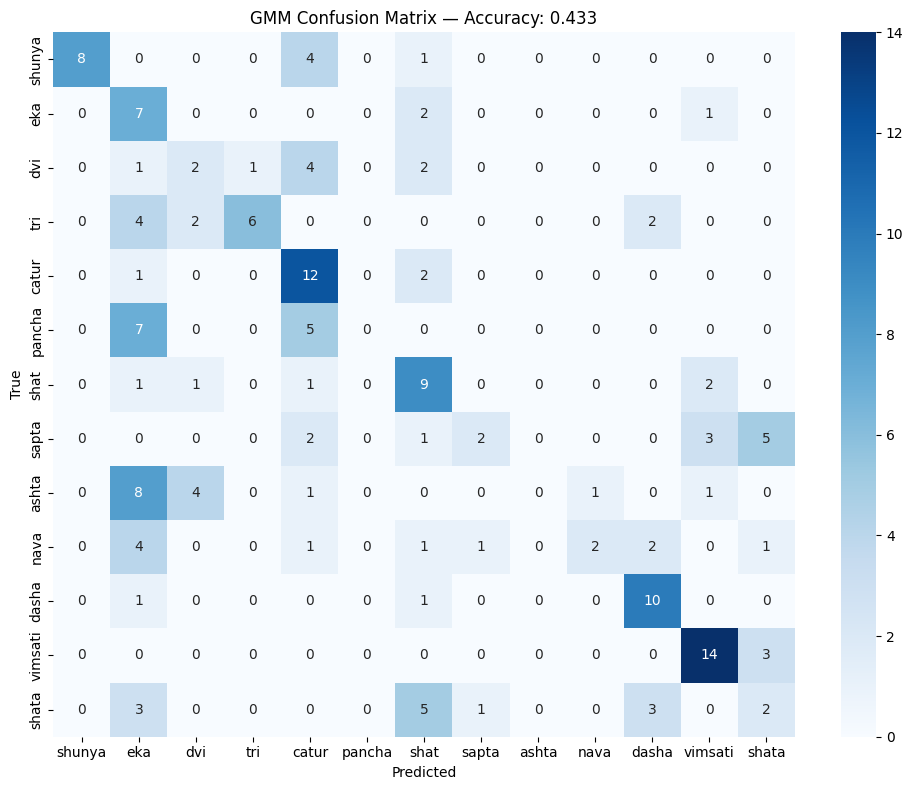


Per-class accuracy:
    shunya (  0): 8/13 = 61.54%
       eka (  1): 7/10 = 70.00%
       dvi (  2): 2/10 = 20.00%
       tri (  3): 6/14 = 42.86%
     catur (  4): 12/15 = 80.00%
    pancha (  5): 0/12 = 0.00%
      shat (  6): 9/14 = 64.29%
     sapta (  7): 2/13 = 15.38%
     ashta (  8): 0/15 = 0.00%
      nava (  9): 2/12 = 16.67%
     dasha ( 10): 10/12 = 83.33%
   vimsati ( 20): 14/17 = 82.35%
     shata (100): 2/14 = 14.29%


In [10]:
# Token label mapping for display
VALUE_TO_TOKEN = {
    0: "shunya", 1: "eka", 2: "dvi", 3: "tri", 4: "catur",
    5: "pancha", 6: "shat", 7: "sapta", 8: "ashta", 9: "nava",
    10: "dasha", 20: "vimsati", 100: "shata",
}

labels_sorted = sorted(set(y_test))
label_names = [VALUE_TO_TOKEN.get(l, str(l)) for l in labels_sorted]

cm = confusion_matrix(y_test, gmm_preds, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=label_names, yticklabels=label_names)
ax.set_title(f"GMM Confusion Matrix — Accuracy: {gmm_acc:.3f}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, l in enumerate(labels_sorted):
    row_total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / row_total if row_total > 0 else 0
    print(f"  {VALUE_TO_TOKEN.get(l, str(l)):>8s} ({l:>3d}): {correct}/{row_total} = {acc:.2%}")